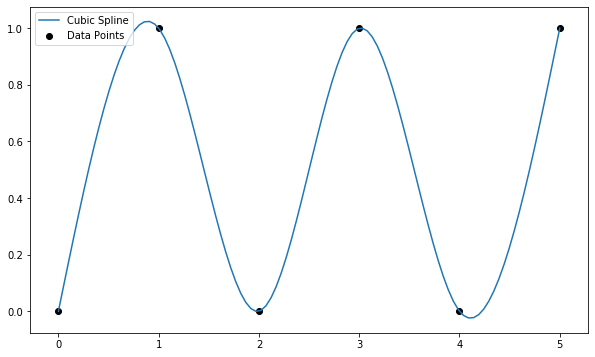

In [20]:
import numpy as np
import matplotlib.pyplot as plt
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)  
    A = np.zeros(n-2) 
    B = np.zeros(n-2) 
    C = np.zeros(n-2) 
    D = np.zeros(n-2) 
    for i in range(1, n-1):
        A[i-1] = h[i-1]  
        B[i-1] = 2 * (h[i-1] + h[i]) 
        C[i-1] = h[i] 
        D[i-1] = 6 * ((y[i+1] - y[i]) / h[i] - (y[i] - y[i-1]) / h[i-1])  
    return A, B, C, D
def thomas_algorithm(a, b, c, d):
    n = len(b)
    for i in range(1, n):
        w = a[i-1] / b[i-1]  
        b[i] = b[i] - w * c[i-1]  
        d[i] = d[i] - w * d[i-1] 
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1] 
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i] 
    return x
def evaluate_spline(x_data, y_data, M, x_eval):
    n = len(x_data)
    h = np.diff(x_data)
    idx = np.searchsorted(x_data, x_eval) - 1
    idx = max(0, min(idx, n-2))
    hi = h[idx]
    xi = x_data[idx]
    xi1 = x_data[idx+1]
    yi = y_data[idx]
    yi1 = y_data[idx+1]
    Mi = M[idx]
    Mi1 = M[idx+1]
    ai = yi
    ci = Mi / 2.0
    di = (Mi1 - Mi) / (6.0 * hi)
    bi = (yi1 - yi) / hi - (hi * (2.0 * Mi + Mi1)) / 6.0
    dx = x_eval - xi
    return ai + bi*dx + ci*(dx**2) + di*(dx**3)
x_points = np.array([0, 1, 2, 3, 4, 5])
y_points = np.array([0, 1, 0, 1, 0, 1])
A, B, C, D = setup_tridiagonal_matrix(x_points, y_points)
M_internal = thomas_algorithm(A, B, C, D)
M = np.zeros(len(x_points))
M[1:-1] = M_internal 
x_vals = np.linspace(min(x_points), max(x_points), 100)
y_vals = [evaluate_spline(x_points, y_points, M, val) for val in x_vals]
plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label='Cubic Spline')
plt.scatter(x_points, y_points,label='Data Points', color='black')
plt.legend()
plt.show()